In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# Question 3

# Question 4

In [2]:
df = pd.read_csv("./data/heart_failure_clinical_records_dataset.csv")
ef = df["ejection_fraction"]
 
xs = np.linspace(ef.min() - 10, ef.max() + 10, 500)

## part a

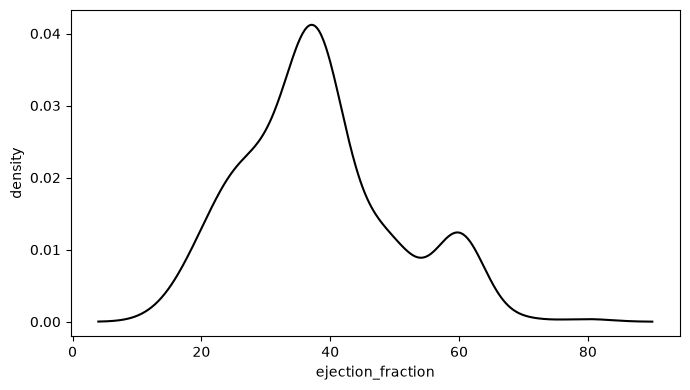

In [8]:
kde0 = gaussian_kde(ef)
plt.figure(figsize=(7, 4))
plt.plot(xs, kde0(xs), color="black")
plt.xlabel("ejection_fraction")
plt.ylabel("density")
plt.tight_layout()
plt.savefig("problem4a.png", dpi=150)

## part b

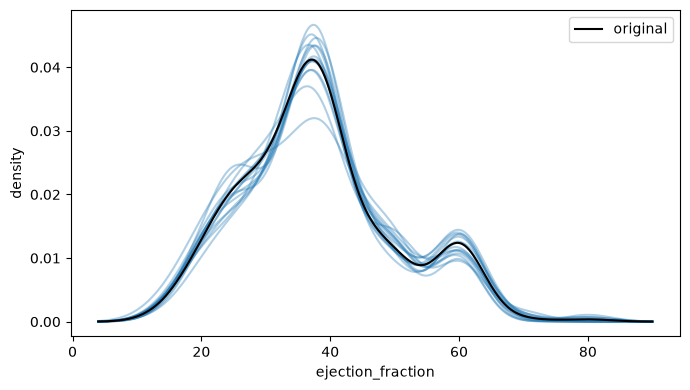

In [11]:
plt.figure(figsize=(7, 4))
for i in range(15):
    boot = df.sample(frac=1.0, replace=True)["ejection_fraction"]
    plt.plot(xs, gaussian_kde(boot)(xs), color="C0", alpha=0.35)
plt.plot(xs, kde0(xs), color="black", label="original")
plt.xlabel("ejection_fraction")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.savefig("problem4b.png", dpi=150)
plt.show()

## part c

The original KDE is most reliable in the tails (below about 15 and above about 65) and on the rising left flank of the main peak (about 20 to 30), where the resampled curves are near zero or tightly bundled, with one small exception near 80 where a single resample picks up a bump from an isolated high observation. The curves vary noticeably at the top of the main peak near 37 (heights of roughly 0.035 to 0.045), at the second bump near 60 (roughly 0.010 to 0.015), and in the stretch from about 45 to 55 between them. So the two-bump shape is stable across resamples, but the exact peak heights and valley depth are uncertain, since they depend on how many of the clustered observations land in each resample.